In [2]:
import warnings
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.exceptions import ConvergenceWarning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

class BatchGDRegressor:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        self.theta = np.zeros(n + 1)

        for _ in range(self.n_iterations):
            predictions = X_b @ self.theta
            errors = predictions - y
            gradients = (1 / m) * (X_b.T @ errors)
            self.theta -= self.learning_rate * gradients

            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)
        return self

    def predict(self, X):
        X = np.array(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.theta


def build_sgd_regressor(learning_rate=0.01, n_iterations=1000, random_state=None):
    return SGDRegressor(
        learning_rate='constant',
        eta0=learning_rate,
        max_iter=n_iterations,
        tol=1e-8,
        penalty=None,
        shuffle=True,
        random_state=random_state
    )


class MiniBatchSGDRegressor:
    def __init__(self, learning_rate=0.01, n_epochs=100, batch_size=32, random_state=None):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.estimator = SGDRegressor(
            learning_rate='constant',
            eta0=learning_rate,
            max_iter=1,    
            tol=None,
            penalty=None,
            shuffle=False, 
            random_state=random_state,
            warm_start=True
        )
        self._is_fitted = False

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.array(X)
        y = np.array(y)
        m = X.shape[0]

        for epoch in range(self.n_epochs):
            indices = rng.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, m, self.batch_size):
                Xi = X_shuffled[i:i + self.batch_size]
                yi = y_shuffled[i:i + self.batch_size]
                self.estimator.partial_fit(Xi, yi)
                self._is_fitted = True
        return self

    def predict(self, X):
        if not self._is_fitted:
            raise ValueError("Model is not fitted yet. Call fit(X, y) before predict.")
        return self.estimator.predict(X)


if __name__ == "__main__":
    from sklearn.datasets import make_regression

    RANDOM_STATE = 42

    X, y = make_regression(n_samples=1000, n_features=5, noise=15, random_state=RANDOM_STATE)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    pipeline = Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', BatchGDRegressor()),
        ]
    )
    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    pipeline.fit(X_train, y_train)

    batch_model = BatchGDRegressor(learning_rate=0.01, n_iterations=500)
    batch_model.fit(X_train, y_train)
    pred_batch = batch_model.predict(X_test)
    mse_batch = mean_squared_error(y_test, pred_batch)
    print("Batch GD MSE:", mse_batch)

    sgd_model = build_sgd_regressor(learning_rate=0.01, n_iterations=500, random_state=RANDOM_STATE)
    sgd_model.fit(X_train, y_train)
    pred_sgd = sgd_model.predict(X_test)
    mse_sgd = mean_squared_error(y_test, pred_sgd)
    print("SGDRegressor (stochastic) MSE:", mse_sgd)

    minibatch_model = MiniBatchSGDRegressor(learning_rate=0.01, n_epochs=200, batch_size=64, random_state=RANDOM_STATE)
    minibatch_model.fit(X_train, y_train)
    pred_minibatch = minibatch_model.predict(X_test)
    mse_minibatch = mean_squared_error(y_test, pred_minibatch)
    print("Mini-Batch (simulated) MSE:", mse_minibatch)

    assert np.isfinite(mse_batch), "Batch MSE is not finite"
    assert np.isfinite(mse_sgd), "SGD MSE is not finite"
    assert np.isfinite(mse_minibatch), "Mini-batch MSE is not finite"

    print("All models trained successfully.\nSummary:")
    print(f"  Batch MSE      : {mse_batch:.4f}")
    print(f"  SGD MSE        : {mse_sgd:.4f}")
    print(f"  Mini-batch MSE : {mse_minibatch:.4f}")





Batch GD MSE: 250.8021590100069
SGDRegressor (stochastic) MSE: 250.38410142472614
Mini-Batch (simulated) MSE: 250.43510963901477
All models trained successfully.
Summary:
  Batch MSE      : 250.8022
  SGD MSE        : 250.3841
  Mini-batch MSE : 250.4351


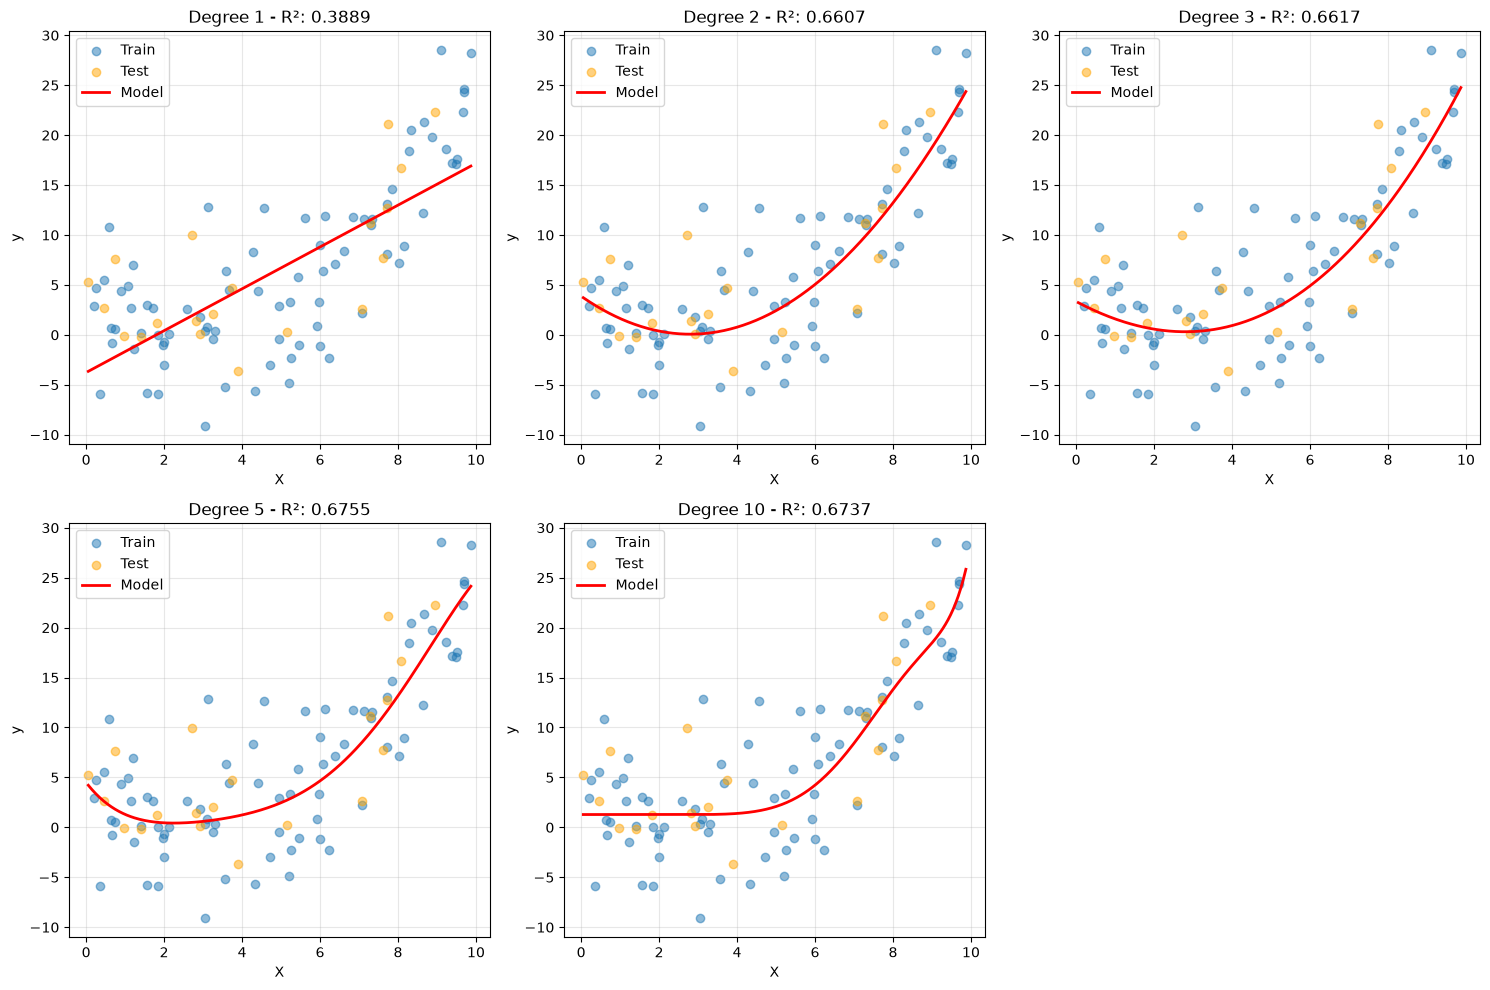

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
np.random.seed(42)
X = np.sort(np.random.rand(100, 1) * 10, axis=0)
y = 0.5 * X**2 - 3 * X + 5 + np.random.randn(100, 1) * 5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = [1, 2, 3, 5, 10]
plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees, 1):
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    poly_model.fit(X_train, y_train)
    
    y_pred = poly_model.predict(X_test)
    
    plt.subplot(2, 3, i)
    plt.scatter(X_train, y_train, alpha=0.5, label='Train')
    plt.scatter(X_test, y_test, alpha=0.5, label='Test', color='orange')
    
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_range = poly_model.predict(X_range)
    plt.plot(X_range, y_range, color='red', linewidth=2, label='Model')
    
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Degree {degree} - R²: {r2_score(y_test, y_pred):.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

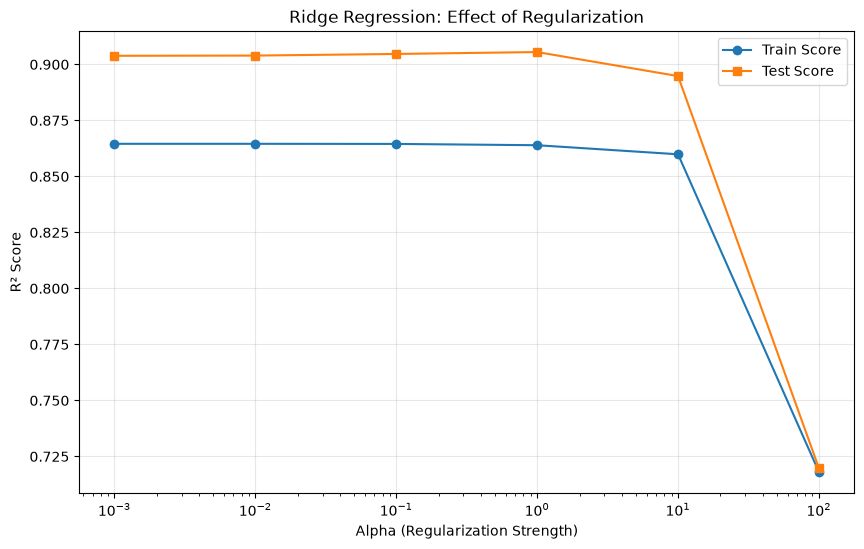

Best alpha: 5.7224
R² Score: 0.9006


In [9]:
from sklearn.linear_model import Ridge, RidgeCV

np.random.seed(42)
n_samples = 100
X1 = np.random.randn(n_samples)
X2 = X1 + np.random.randn(n_samples) * 0.1 
X3 = np.random.randn(n_samples)
X = np.column_stack([X1, X2, X3])
y = 3*X1 + 2*X2 + 1*X3 + np.random.randn(n_samples) * 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    train_scores.append(ridge.score(X_train, y_train))
    test_scores.append(ridge.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(alphas, train_scores, label='Train Score', marker='o')
plt.plot(alphas, test_scores, label='Test Score', marker='s')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Effect of Regularization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(X_train, y_train)
print(f"Best alpha: {ridge_cv.alpha_:.4f}")
print(f"R² Score: {ridge_cv.score(X_test, y_test):.4f}")

Best alpha: 0.0534
R² Score: 0.9773
Number of non-zero coefficients: 7


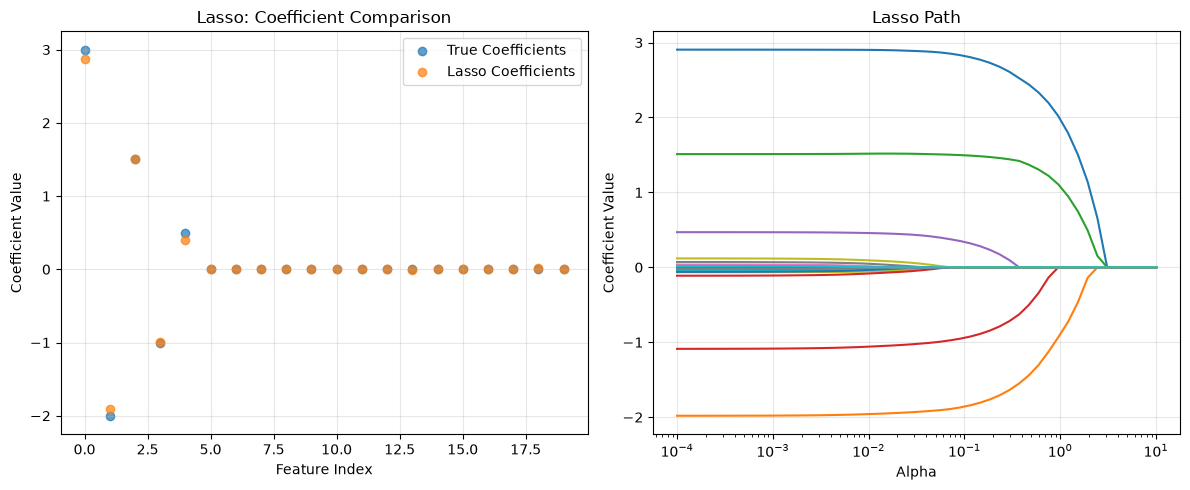

In [10]:
from sklearn.linear_model import Lasso, LassoCV

np.random.seed(42)
n_samples, n_features = 100, 20
X = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features)
true_coef[:5] = [3, -2, 1.5, -1, 0.5]
y = X @ true_coef + np.random.randn(n_samples) * 0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f"Best alpha: {lasso_cv.alpha_:.4f}")
print(f"R² Score: {lasso_cv.score(X_test, y_test):.4f}")
print(f"Number of non-zero coefficients: {np.sum(lasso_cv.coef_ != 0)}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(n_features), true_coef, label='True Coefficients', alpha=0.7)
plt.scatter(range(n_features), lasso_cv.coef_, label='Lasso Coefficients', alpha=0.7)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Lasso: Coefficient Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
alphas_test = np.logspace(-4, 1, 50)
coefs = []
for alpha in alphas_test:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

plt.plot(alphas_test, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Path')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# logistic regression


class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_probability(self,X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)
        

    def predict(self,X):
        probabilities = self.predict_probability(X)
        return np.array([1 if i > 0.5 else 0 for i in probabilities])


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, 
                           random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f'Accuracy: {acc:.2f}')
print(f'Conf Matrix: {cm}')
print(f'Report:\n {report}')


Accuracy: 0.90
Conf Matrix: [[97  7]
 [13 83]]
Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       104
           1       0.92      0.86      0.89        96

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200

